# Exercise 1

Deadline 6.11.2025

## 1. Two dimensional data

In [2]:
from sklearn.datasets import make_moons
import numpy as np
import matplotlib.pyplot as plt

from numpy import exp, sqrt, pi

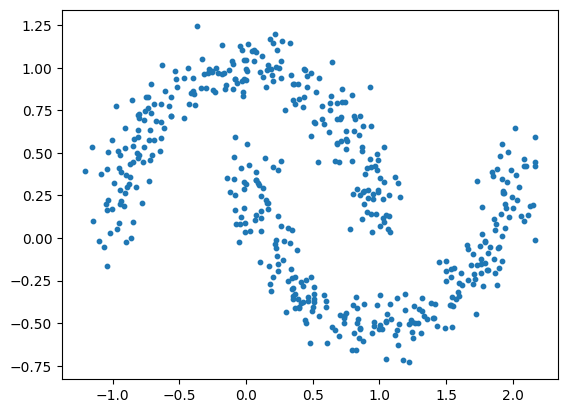

In [3]:
# Plot
X, y = make_moons(n_samples = 500, noise = 0.1, random_state = 42)
plt.scatter(X[:, 0], X[:, 1], s=10)

# Implement a class for each of the following models, including
# methods for fit(), sample(), and score_samples()

Next, we will implement classes, à la sklearn, providing methods for fit(), sample() and score_samples() without using the pre-defined classes, but formulating them independently.

We will create a class for each of the following models:

1. two-dimensional histogram
2. single Gaussian
3. Gaussian mixture model
4. kernel density estimator with a Gaussian kernel

For evaluation, we will implement the maximum mean discrepancy metric with squared exponential and inverse multi-quadratic kernels

$$ \mathrm{se}(x, x') = \mathrm{exp}(-\dfrac{||{x-x'}||^2}{h^2})$$

$$ \mathrm{imq}(x, x') = \dfrac{1}{\sqrt{1 + \dfrac{||{x-x'}||^2}{h^2}}}$$

### 1.1 Two dimensional histogram

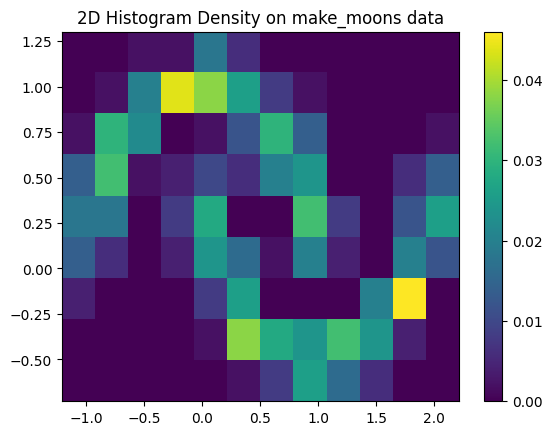

(12, 9)


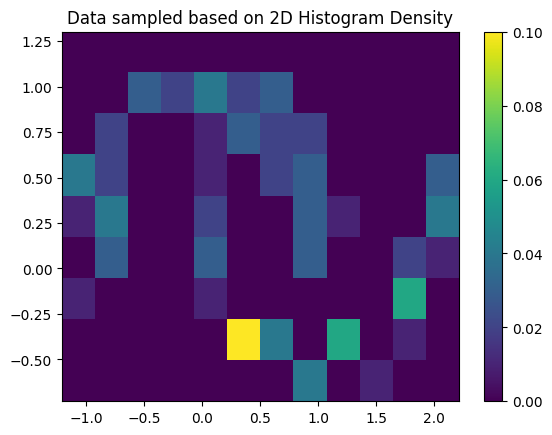

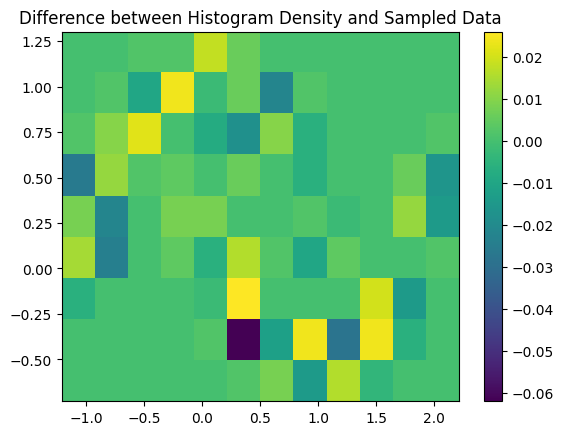

(500, 2) (12, 9)
(500, 2) (12, 9)
Score (se):  None
Score (imq): None


In [4]:

class two_dim_histogram:
    def __init__(self):
        self.densities = None
        self.bin_edges_1 = None
        self.bin_edges_2 = None
        self.samples = None
        self.score = None
    # Method to fit 2d histogram
    '''
    As in 1d, need to determine p_k and bin sizes.
    
    In 1d, determined the bin sizes with the interquantile range IQR

        h_1D = 2 IQR / (N)^(1/3)

    In 2d, do the same in both dimensions
    '''
    def fit(self, X, y): # training_data := X, classes := y
        # Get n_samples
        n_samples = X.shape[0]

        # Determine Interquantile range
        # IQR = x_[3N/4] - x_[N/4]
        IQR_x1 = np.percentile(X[:, 0], 75) - np.percentile(X[:, 0], 25)
        IQR_x2 = np.percentile(X[:, 1], 75) - np.percentile(X[:, 1], 25)

        # Bin widths
        h_1 = 2 * IQR_x1 / ((n_samples) ** (1/3))
        h_2 = 2 * IQR_x2 / ((n_samples) ** (1/3))

        # Create bins k
        x1_min, x1_max = np.min(X[:, 0]), np.max(X[:, 0])
        x2_min, x2_max = np.min(X[:, 1]), np.max(X[:, 1])
        self.bin_edges_1 = np.arange(x1_min, x1_max + h_1, h_1)
        self.bin_edges_2 = np.arange(x2_min, x2_max + h_2, h_2)

        # Determine counts in bins k
        counts, _, _ = np.histogram2d(X[:, 0], X[:, 1], bins = [self.bin_edges_1, self.bin_edges_2])
        self.densities = counts / counts.sum()

        return self.densities, self.bin_edges_1, self.bin_edges_2

    # Method to sample
    def sample(self, n_samples):
        # First select bins based on densities
        '''
        This creates an array n_samples large where every entry marks the bin number
        from which we should sample
        '''
        bin_indices = np.random.choice(self.densities.size, 
            size = n_samples, 
            p = self.densities.flatten()) # flatten because only takes 1d array or int

        # Count instances of selected bins
        samples = np.bincount(bin_indices, 
                              minlength = self.densities.size
                              ).reshape(self.densities.shape)
        self.samples = samples / samples.sum()

        return self.samples

    # Method to score samples
    def score_samples(self, X, h = 1, kernel = "squared_exponential"):
        # Implement MMD^2 metric with se, imq kernels
        # Need to vectorize MMD calculation because for loops (sums) are very inefficient in python
        # MMD^2 = Term1 + Term2 - Term3, can neglect Term1 because it is model independent
        """
        MMD^2 = 0
        for i in range(1,N):
            for i_prime != i:
                MMD^2 += k(x_i, x_i_prime)

        for j in range(1, N_prime):
            for j_prime != j:
                MMD^2 += k(x_prime_j, x_prime_j_prime)

        for i in range(1, N):
            for j in range(1, N_prime):
                MMD^2 += -2 k(x_i, x_prime_j)
        """
        # Instead, we want to calculate it using something like this:
        """
        MMD^2 = k(distance_matrix_x).sum() 
            + k(distance_matrix_x_prime).sum() 
            - 2 k(distance_matrix_xx_prime).sum()
        """
        # Calculate Distance matrices D as: 
        # D[i, j] = || x_i - x_i_prime ||_2^2 = ||x||_2^2 + ||x_prime||_2^2 - 2 x.T @ x_prime
        # D_XX = self.calculate_distance_matrix(X, X) Can be neglected
        #D_XprimeXprime = self.calculate_distance_matrix(self.samples, self.samples)
        #D_XXprime = self.calculate_distance_matrix(X, self.samples)

        # Depending on selected kernel, calculate MMD^2
        N = X.shape[0]
        Nprime = self.samples.shape[0]
        #if kernel == "squared_exponential":
         #   MMD_sq = (self.squared_exponential(D_XprimeXprime, h).sum() / (Nprime * (Nprime - 1))
          #            - 2 * self.squared_exponential(D_XXprime, h).sum() / (N * Nprime))
        #elif kernel == "inverse_multi_quadratic":
         #   MMD_sq = (self.inverse_multi_quadratic(D_XprimeXprime, h).sum() / (Nprime * (Nprime - 1))
          #            - 2 * self.inverse_multi_quadratic(D_XXprime, h).sum() / (N * Nprime))
        #else:
         #   raise ValueError("Please select either 'squared_exponential' or 'inverse_multi_quadratic'")

        #self.score = MMD_sq
        print(X.shape, self.samples.shape)
        return self.score
    
    def calculate_distance_matrix(self, A, B):
        # D_ij = ||A_i - B_j||^2 = ||A_i||^2 + ||B_j||^2 - 2 A_i @ B_j.T
        # A_sq in (N_A, 1)
        A_sq = np.sum(A ** 2, axis = 1, keepdims = True)
        # B_sq in (1, N_B)
        B_sq = np.sum(B ** 2, axis = 1, keepdims = True).T # .T otherwise won't work if samples, data different dimension
        print("A", A_sq.shape, "B", B_sq.shape)
        AB_T = A @ B.T
        D_AB = A_sq + B_sq - 2 * AB_T
        return D_AB
        
    def squared_exponential(self, D_AB, h):
        return exp(- D_AB / (h ** 2))   
    
    def inverse_multi_quadratic(self, D_AB, h):
        return 1 / sqrt(1 + D_AB / (h ** 2))

# Fit 2d histogram model
model = two_dim_histogram()
make_moons_histogram2d, edges_1, edges_2 = model.fit(X, y)

# Plot 2d histogram density
plt.figure()
plt.title("2D Histogram Density on make_moons data")
plt.imshow(make_moons_histogram2d.T, 
           extent=[edges_1[0], edges_1[-1], edges_2[0], edges_2[-1]], 
           origin='lower', 
           cmap='viridis', 
           aspect='auto')
plt.colorbar()
plt.show()

# Sample from histogram
samples = model.sample(100)
print(samples.shape)
plt.figure()
plt.title("Data sampled based on 2D Histogram Density")
plt.imshow(samples.T, 
           extent=[edges_1[0], edges_1[-1], edges_2[0], edges_2[-1]], 
           origin='lower', 
           cmap='viridis', 
           aspect='auto')
plt.colorbar()
plt.show()

# Comparison between Histogram Density and Sampled data
plt.figure()
plt.title("Difference between Histogram Density and Sampled Data")
plt.imshow(make_moons_histogram2d.T - samples.T, 
           extent=[edges_1[0], edges_1[-1], edges_2[0], edges_2[-1]], 
           origin='lower', 
           cmap='viridis', 
           aspect='auto')
plt.colorbar()
plt.show()

# Score
score_se = model.score_samples(X, h = 0.05, kernel = "squared_exponential")
score_imq = model.score_samples(X, h = 0.05, kernel = "inverse_multi_quadratic")

print(f"Score (se):  {score_se}")
print(f"Score (imq): {score_imq}")

### 1.2 Single Gaussian

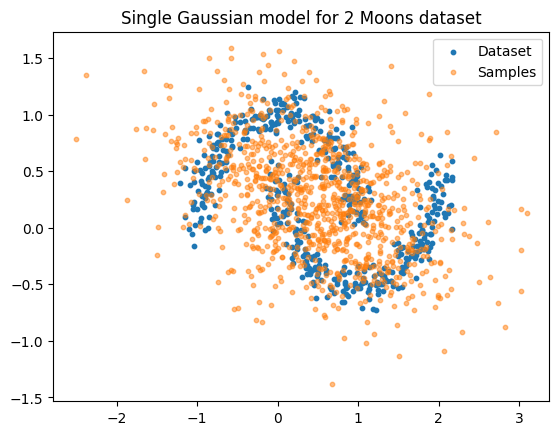

Score (se):  -0.00011724926539348132


In [50]:
class single_gaussian:
    def __init__(self):
        self.mu = None
        self.Sigma = None
        self.samples = None
        self.score = None
    # Method to fit a single Gaussian
    '''
    Need to determine appropriate mu, sigma for a single Gaussian on top of the data
    '''
    def fit(self, X): # training_data := X
        # Gaussian with simply mu = np.mean, Sigma = np.cov
        self.mu = np.mean(X, axis = 0)
        self.Sigma = np.cov(X, rowvar = False)

        return self.mu, self.Sigma
    
    def sample(self, n_samples):
        self.samples = np.random.multivariate_normal(self.mu, self.Sigma, n_samples)
        return self.samples

    # Method to score samples
    def score_samples(self, X, h = 1, kernel = "squared_exponential"):
        # Implement MMD^2 metric with se, imq kernels
        # Need to vectorize MMD calculation because for loops (sums) are very inefficient in python
        # MMD^2 = Term1 + Term2 - Term3, can neglect Term1 because it is model independent
        """
        MMD^2 = 0
        for i in range(1,N):
            for i_prime != i:
                MMD^2 += k(x_i, x_i_prime)

        for j in range(1, N_prime):
            for j_prime != j:
                MMD^2 += k(x_prime_j, x_prime_j_prime)

        for i in range(1, N):
            for j in range(1, N_prime):
                MMD^2 += -2 k(x_i, x_prime_j)
        """
        # Instead, we want to calculate it using something like this:
        """
        MMD^2 = k(distance_matrix_x).sum() 
            + k(distance_matrix_x_prime).sum() 
            - 2 k(distance_matrix_xx_prime).sum()
        """
        # Calculate Distance matrices D as: 
        # D[i, j] = || x_i - x_i_prime ||_2^2 = ||x||_2^2 + ||x_prime||_2^2 - 2 x.T @ x_prime
        # D_XX = self.calculate_distance_matrix(X, X) Can be neglected
        D_XprimeXprime = self.calculate_distance_matrix(self.samples, self.samples)
        D_XXprime = self.calculate_distance_matrix(X, self.samples)

        # Depending on selected kernel, calculate MMD^2
        N = X.shape[0]
        Nprime = self.samples.shape[0]
        if kernel == "squared_exponential":
            MMD_sq = (self.squared_exponential(D_XprimeXprime, h).sum() / (Nprime ** 2)
                      - 2 * self.squared_exponential(D_XXprime, h).sum() / (N * Nprime))
        elif kernel == "inverse_multi_quadratic":
            MMD_sq = (self.inverse_multi_quadratic(D_XprimeXprime, h).sum() / (Nprime ** 2)
                      - 2 * self.inverse_multi_quadratic(D_XXprime, h).sum() / (N * Nprime))
        else:
            raise ValueError("Please select either 'squared_exponential' or 'inverse_multi_quadratic'")
        """
        In the lecture we derived the formula where we sum over i, then sum over i != j. The kernels 
        k(i, i) are not 0, but 1. We still sum over them in the vectorization. For that reason, 
        we adjust the denominator to N^2, N'^2 instead of N(N-1), N'(N'-1)
        """

        self.score = MMD_sq

        return self.score
    
    def calculate_distance_matrix(self, A, B):
        # D_ij = ||A_i - B_j||^2 = ||A_i||^2 + ||B_j||^2 - 2 A_i @ B_j.T
        # A_sq in (N_A, 1)
        A_sq = np.sum(A ** 2, axis = 1, keepdims = True)
        # B_sq in (1, N_B)
        B_sq = np.sum(B ** 2, axis = 1, keepdims = True).T # .T otherwise won't work if samples, data different dimension
        AB_T = A @ B.T
        D_AB = A_sq + B_sq - 2 * AB_T
        return D_AB
        
    def squared_exponential(self, D_AB, h):
        return exp(- D_AB / (h ** 2))   
    
    def inverse_multi_quadratic(self, D_AB, h):
        return 1 / sqrt(1 + D_AB / (h ** 2))

# Fit 2d single Gaussian model
model = single_gaussian()
make_moons_single_gaussian = model.fit(X)

# Sample from Gaussian
samples = model.sample(n_samples = 1000)
plt.figure()
plt.title("Single Gaussian model for 2 Moons dataset")
plt.scatter(X[:, 0], X[:, 1], s=10, 
            label = "Dataset")
plt.scatter(samples[:, 0], samples[:, 1],
            alpha = 0.5, 
            s = 10,
            label = "Samples")
plt.legend()
plt.show()

# Score
score_se = model.score_samples(X, h = 0.05, kernel = "squared_exponential")
#score_imq = model.score_samples(h = 0.05, metric = "inverse_multi_quadratic")

print(f"Score (se):  {score_se}")
#print(f"Score (imq): {score_imq}")

### 1.3 Gaussian Mixture Model

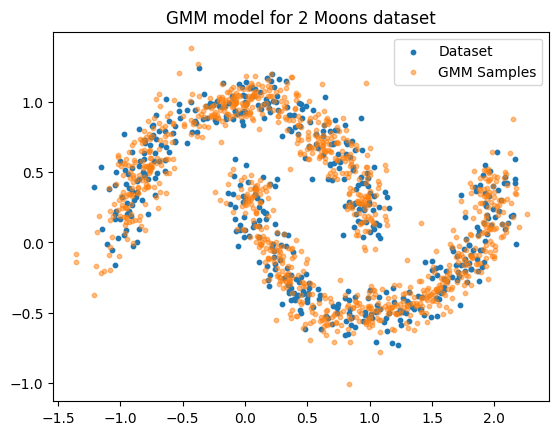

Score (se):  -0.002175421356131478
Score (imq): -0.06839858950145179


In [51]:
from scipy.stats import multivariate_normal

class gaussian_mixture_model:
    def __init__(self, n_terms = 1, steps = 100):
        self.mus = None
        self.Sigmas = None
        self.Pis = None
        self.samples = None
        self.score = None
        self.n_terms = n_terms
        self.steps = steps

    '''
    p_hat = sum_{m = 1}^M Pi_m N(mu_m, Sigma_m), where mu_m, Sigma_m
    can be found through expectation maximization algorithm from 1D.

    Basics:
    (0) Initialize Sigma_k = Id, mu_k random datapoint, Pi_k^(0) = 1 / M
    (1) for step t or until convergence:
        a) calc. performance
            gamma_ik^(t) = Pi_k^(t-1) N(x_i | mu_k^(t-1), Sigma_k^(t-1)) / p^(t-1)(x_i)
        b) update mu_k^(t), Sigma_k^(t)
            Pi_k^(t) = 1/N sum_{i=1}^N gamma_ik
            mu_k^(t) = sum_{i=1}^N gamma_ik x_i / sum_{i=1}^N gamma_ik
            Sigma_k^(t) ...
    '''

    def initialize_parameters(self, X):
        N, D = X.shape
        M = self.n_terms

        # Initialize for t = 0
        random_indices = np.random.choice(N, M, replace = False)
        self.mus = X[random_indices]
        self.Pis = np.ones(M) / M
        self.Sigmas = np.array([np.eye(D) for _ in range(M)])

    # Method to fit GMM
    def fit(self, X): # training_data := X
        
        # Initialize parameters
        self.initialize_parameters(X)
        self.N, self.D = X.shape
        self.M = self.n_terms

        # Expectation Maximization algorithm
        for t in range(self.steps):
            self.gamma_ik = np.zeros((self.N, self.M))
            # a) Calculate gamma_ik
            for k in range(self.M):
                self.gamma_ik[:, k] = self.Pis[k] * multivariate_normal.pdf(X, mean = self.mus[k], cov = self.Sigmas[k])

            # Normalize gamma_ik
            self.gamma_ik /= np.sum(self.gamma_ik, axis = 1, keepdims = True)
            
            # b) Update parameters
            # Calculate mus
            self.Pis = np.mean(self.gamma_ik, axis = 0)
            self.mus = (self.gamma_ik.T @ X) / np.sum(self.gamma_ik, axis = 0)[:, np.newaxis]
            # Calculate Sigmas: sum_i gamma_ik (x - mu)^T (x - mu) / sum_i gamma_ik
            # Define a small regularization constant to keep cov positive definite
            REG_COV = 1e-6
            for k in range(self.M):
                X_centered = X - self.mus[k]
                weighted_X_centered = X_centered * self.gamma_ik[:, k][:, np.newaxis]
                self.Sigmas[k] = weighted_X_centered.T @ X_centered / np.sum(self.gamma_ik[:, k], axis = 0) + REG_COV * np.eye(self.D)

        return self.mus, self.Sigmas
    
    def sample(self, n_samples):
        # Sample from GMM
        # 1. Pick from which Gaussian to sample based on weighs Pi_k
        component_indices = np.random.choice(self.M, size = n_samples, p = self.Pis)
        # Initialize samples array
        self.samples = np.zeros((n_samples, self.D))
        # 2. Sample from selected Gaussian
        for k in range(self.M):
            # Count instances where Gaussian k was selected
            n_k = np.sum(component_indices == k)
            if n_k > 0:
                self.samples[component_indices == k] = np.random.multivariate_normal(
                    self.mus[k], self.Sigmas[k], n_k)

        return self.samples
    
    # Method to score samples
    def score_samples(self, X, h = 1, kernel = "squared_exponential"):
        # Implement MMD^2 metric with se, imq kernels
        # Need to vectorize MMD calculation because for loops (sums) are very inefficient in python
        # MMD^2 = Term1 + Term2 - Term3, can neglect Term1 because it is model independent
        """
        MMD^2 = 0
        for i in range(1,N):
            for i_prime != i:
                MMD^2 += k(x_i, x_i_prime)

        for j in range(1, N_prime):
            for j_prime != j:
                MMD^2 += k(x_prime_j, x_prime_j_prime)

        for i in range(1, N):
            for j in range(1, N_prime):
                MMD^2 += -2 k(x_i, x_prime_j)
        """
        # Instead, we want to calculate it using something like this:
        """
        MMD^2 = k(distance_matrix_x).sum() 
            + k(distance_matrix_x_prime).sum() 
            - 2 k(distance_matrix_xx_prime).sum()
        """
        # Calculate Distance matrices D as: 
        # D[i, j] = || x_i - x_i_prime ||_2^2 = ||x||_2^2 + ||x_prime||_2^2 - 2 x.T @ x_prime
        # D_XX = self.calculate_distance_matrix(X, X) Can be neglected
        D_XprimeXprime = self.calculate_distance_matrix(self.samples, self.samples)
        D_XXprime = self.calculate_distance_matrix(X, self.samples)

        # Depending on selected kernel, calculate MMD^2
        N = X.shape[0]
        Nprime = self.samples.shape[0]
        if kernel == "squared_exponential":
            MMD_sq = (self.squared_exponential(D_XprimeXprime, h).sum() / (Nprime ** 2)
                      - 2 * self.squared_exponential(D_XXprime, h).sum() / (N * Nprime))
        elif kernel == "inverse_multi_quadratic":
            MMD_sq = (self.inverse_multi_quadratic(D_XprimeXprime, h).sum() / (Nprime ** 2)
                      - 2 * self.inverse_multi_quadratic(D_XXprime, h).sum() / (N * Nprime))
        else:
            raise ValueError("Please select either 'squared_exponential' or 'inverse_multi_quadratic'")
        """
        In the lecture we derived the formula where we sum over i, then sum over i != j. The kernels 
        k(i, i) are not 0, but 1. We still sum over them in the vectorization. For that reason, 
        we adjust the denominator to N^2, N'^2 instead of N(N-1), N'(N'-1)
        """

        self.score = MMD_sq

        return self.score

    
    def calculate_distance_matrix(self, A, B):
        # D_ij = ||A_i - B_j||^2 = ||A_i||^2 + ||B_j||^2 - 2 A_i @ B_j.T
        # A_sq in (N_A, 1)
        A_sq = np.sum(A ** 2, axis = 1, keepdims = True)
        # B_sq in (1, N_B)
        B_sq = np.sum(B ** 2, axis = 1, keepdims = True).T # .T otherwise won't work if samples, data different dimension
        AB_T = A @ B.T
        D_AB = A_sq + B_sq - 2 * AB_T
        return D_AB
        
    def squared_exponential(self, D_AB, h):
        return exp(- D_AB / (h ** 2))   
    
    def inverse_multi_quadratic(self, D_AB, h):
        return 1 / sqrt(1 + D_AB / (h ** 2))

    

# Test GMM
model = gaussian_mixture_model(n_terms = 10, steps = 100)
make_moons_gmm = model.fit(X)

# Plot calculated GMM over data
samples = model.sample(1000)
plt.figure()
plt.title("GMM model for 2 Moons dataset")
plt.scatter(X[:, 0], X[:, 1], s=10, 
            label = "Dataset")
plt.scatter(samples[:, 0], samples[:, 1],
            alpha = 0.5, 
            s = 10, 
            label = "GMM Samples")
plt.legend()       
plt.show()

# Score
score_se = model.score_samples(X, h = 0.05, kernel = "squared_exponential")
score_imq = model.score_samples(X, h = 0.05, kernel = "inverse_multi_quadratic")

print(f"Score (se):  {score_se}")
print(f"Score (imq): {score_imq}")

### Evaluation of models

Starting GMM and Single Gaussian MMD Evaluation...
K=1, h=0.01: MMD_se=0.0010, MMD_imq=-0.0111
K=1, h=0.1: MMD_se=-0.0028, MMD_imq=-0.1127
K=1, h=0.5: MMD_se=-0.1065, MMD_imq=-0.4351
K=1, h=1.0: MMD_se=-0.3305, MMD_imq=-0.6535
K=2, h=0.01: MMD_se=0.0009, MMD_imq=-0.0117
K=2, h=0.1: MMD_se=-0.0047, MMD_imq=-0.1167
K=2, h=0.5: MMD_se=-0.1141, MMD_imq=-0.4385
K=2, h=1.0: MMD_se=-0.3333, MMD_imq=-0.6547
K=3, h=0.01: MMD_se=0.0009, MMD_imq=-0.0123
K=3, h=0.1: MMD_se=-0.0060, MMD_imq=-0.1209
K=3, h=0.5: MMD_se=-0.1237, MMD_imq=-0.4443
K=3, h=1.0: MMD_se=-0.3420, MMD_imq=-0.6578
K=5, h=0.01: MMD_se=0.0009, MMD_imq=-0.0132
K=5, h=0.1: MMD_se=-0.0089, MMD_imq=-0.1258
K=5, h=0.5: MMD_se=-0.1301, MMD_imq=-0.4463
K=5, h=1.0: MMD_se=-0.3419, MMD_imq=-0.6579
K=10, h=0.01: MMD_se=0.0009, MMD_imq=-0.0138
K=10, h=0.1: MMD_se=-0.0110, MMD_imq=-0.1285
K=10, h=0.5: MMD_se=-0.1328, MMD_imq=-0.4474
K=10, h=1.0: MMD_se=-0.3426, MMD_imq=-0.6582
K=15, h=0.01: MMD_se=0.0009, MMD_imq=-0.0137
K=15, h=0.1: MMD_se=

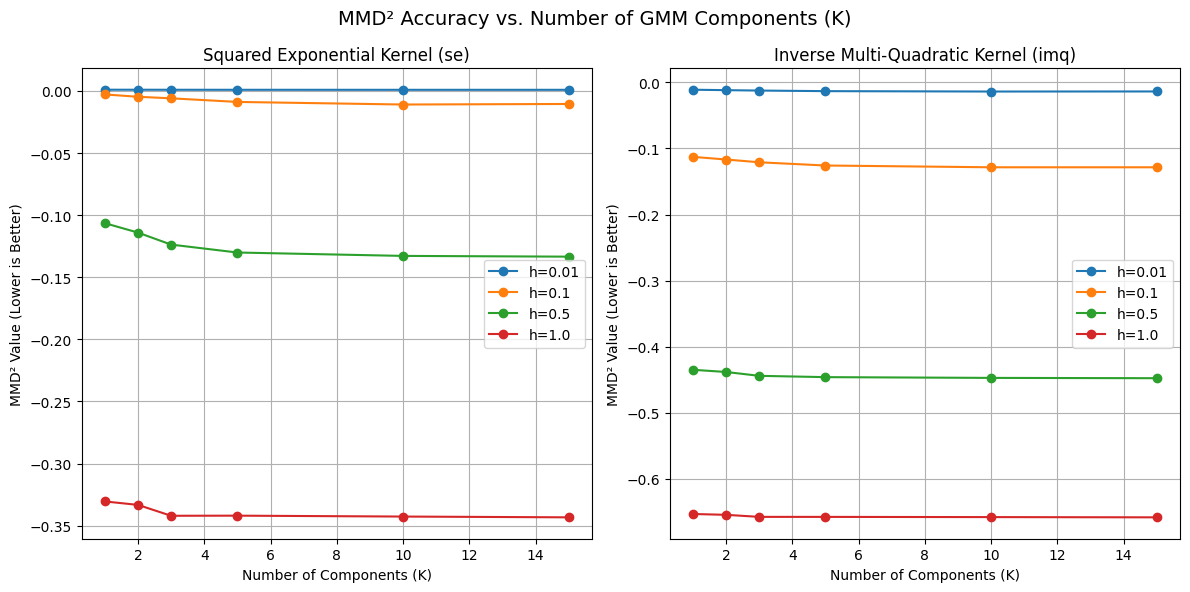

In [ ]:
# setup
N_train = 500  
N_test = 1000  
N_samples = 1000 

# Create a fixed test set for consistent MMD comparison
X_test, _ = make_moons(N_samples = N_test, noise=0.1, random_state=42)
X_train, _ = make_moons(N_samples = N_train, noise=0.1, random_state=10)

# Hyperparams
M_values = [1, 2, 3, 5, 10, 15] 
H_values = [0.01, 0.1, 0.5, 1.0] 

# Store MMD^2 results
mmd_results = np.zeros((len(M_values), len(H_values), 2)) # 2 for se, imq

# Start evaluation
for i, M in enumerate(M_values):
    # 1. Fit Model (GMM, K=1 is equivalent to Single Gaussian)

    if M == 1:
        # Use single_gaussian for M=1 to directly test the equivalence
        model = single_gaussian()
        model.fit(X_train)
    else:
        model = gaussian_mixture_model(n_terms = M, steps = 100)
        model.fit(X_train)

    # 2. Generate Samples for MMD Test
    X_generated = model.sample(N_samples)
    
    # 3. Calculate MMD for different bandwidths h
    for j, h in enumerate(H_values):
        # We use the MMD logic from the single_gaussian class, as MMD is model-agnostic
        # If model is GMM, we must use a dummy single_gaussian instance to call score_samples
        mmd_calculator = single_gaussian()
        mmd_calculator.samples = X_generated # Set the generated samples (Y)

        # Squared Exponential (se)
        mmd_se = mmd_calculator.score_samples(X = X_test, h=h, kernel="squared_exponential")
        mmd_results[i, j, 0] = mmd_se
        
        # Inverse Multi-Quadratic (imq)
        mmd_imq = mmd_calculator.score_samples(X = X_test, h=h, kernel="inverse_multi_quadratic")
        mmd_results[i, j, 1] = mmd_imq
        
        print(f"K={K}, h={h}: MMD_se={mmd_se:.4f}, MMD_imq={mmd_imq:.4f}")

# --- Plot MMD Accuracy vs. GMM Components (K) ---
plt.figure(figsize=(12, 6))
plt.suptitle('MMD² Accuracy vs. Number of GMM Components (K)', fontsize=14)

# Plot for Squared Exponential Kernel
plt.subplot(1, 2, 1)
plt.title(f'Squared Exponential Kernel (se)')
for j, h in enumerate(H_values):
    plt.plot(M_values, mmd_results[:, j, 0], marker='o', label=f'h={h}')
plt.xlabel('Number of Components (K)')
plt.ylabel('MMD² Value (Lower is Better)')
plt.legend()
plt.grid(True)

# Plot for Inverse Multi-Quadratic Kernel
plt.subplot(1, 2, 2)
plt.title(f'Inverse Multi-Quadratic Kernel (imq)')
for j, h in enumerate(H_values):
    plt.plot(M_values, mmd_results[:, j, 1], marker='o', label=f'h={h}')
plt.xlabel('Number of Components (K)')
plt.ylabel('MMD² Value (Lower is Better)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()